# Exercise 01: Simulación y Regresión Lineal

**Objetivo**: generar datos sintéticos y recuperar los β verdaderos mediante regresión lineal.  Mediante regresión lineal, análisis de residuos, métricas adicionales, interacción, variable cuadrática y convergencia de coeficientes.


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score  # Añadir esta línea
from scipy import stats

# Parámetros verdaderos
beta_0, beta_1, beta_2 = 1.1, -8.2, 5.0
sigma = 2.0
# Parámetros para Gamma
alpha, scale = 2.0, 1.0
# Tamaños de muestra para análisis
sample_sizes = [50, 100, 200, 500, 1000, 2000]

# Funciones de simulación
def simulate_simple(n, seed=None):
    rng = np.random.default_rng(seed)
    x1 = rng.normal(5, 7, size=n)
    eps = rng.normal(0, sigma, size=n)
    y = beta_0 + beta_1 * x1 + eps
    return x1, y

def simulate_gamma(n, seed=None):
    rng = np.random.default_rng(seed)
    x1 = rng.normal(5, 7, n)
    x2 = rng.gamma(alpha, scale, n)
    eps = rng.normal(0, sigma, n)
    y  = beta_0 + beta_1 * x1 + beta_2 * x2 + eps
    return pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})

def simulate_with_z(n, seed=None):
    df = simulate_gamma(n, seed)
    df['z'] = df['x1']**2
    return df

# Paso 1: Simulación simple y visualización



In [ ]:
# Funciones de simulación originales

def simulate_simple(n, seed=None):
    rng = np.random.default_rng(seed)
    x1 = rng.normal(5, 7, size=n)
    eps = rng.normal(0, sigma, size=n)
    y = beta_0 + beta_1 * x1 + eps
    return x1, y

def simulate_gamma(n, seed=None):
    rng = np.random.default_rng(seed)
    x1 = rng.normal(5, 7, n)
    x2 = rng.gamma(alpha, scale, n)
    eps = rng.normal(0, sigma, n)
    y  = beta_0 + beta_1 * x1 + beta_2 * x2 + eps
    return pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})

def simulate_with_z(n, seed=None):
    df = simulate_gamma(n, seed)
    df['z'] = df['x1']**2
    return df





In [20]:
# Funciones de mejora sugeridas
def simulate_with_different_errors(n, error_type='normal', seed=None):
    rng = np.random.default_rng(seed)
    x1 = rng.normal(5, 7, n)
    if error_type == 'normal':
        eps = rng.normal(0, sigma, n)
    elif error_type == 'uniform':
        eps = rng.uniform(-2*sigma, 2*sigma, n)
    elif error_type == 't':
        eps = rng.standard_t(df=3, size=n) * sigma
    else:
        raise ValueError("error_type debe ser 'normal', 'uniform' o 't'")
    y = beta_0 + beta_1 * x1 + eps
    return x1, eps, y

def simulate_with_more_distributions(n, seed=None):
    rng = np.random.default_rng(seed)
    return pd.DataFrame({
        'x1': rng.normal(5, 7, n),
        'x2': rng.gamma(alpha, scale, n),
        'x3': rng.poisson(lam=2, size=n),
        'x4': rng.binomial(n=10, p=0.3, size=n)
    })

def evaluate_with_cv(X, y, k=5):
    model = LinearRegression()
    scores = cross_val_score(model, X, y, cv=k, scoring='neg_mean_squared_error')
    return -scores.mean()

def compute_confidence_intervals(model, X, y):
    n = len(y)
    p = X.shape[1]
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    X_matrix = np.column_stack([np.ones(n), X])
    var_b = mse * np.linalg.inv(X_matrix.T @ X_matrix).diagonal()
    se_b = np.sqrt(var_b)
    t_val = stats.t.ppf(0.975, df=n-p-1)
    ci_lower = model.coef_ - t_val * se_b[1:]
    ci_upper = model.coef_ + t_val * se_b[1:]
    return ci_lower, ci_upper

def plot_diagnostic_plots(model, X, y):
    y_pred = model.predict(X)
    residuals = y - y_pred

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    stats.probplot(residuals, dist="norm", plot=axes[0,0])
    axes[0,0].set_title("Normal Q-Q")

    axes[0,1].scatter(y_pred, residuals, alpha=0.6)
    axes[0,1].axhline(0, linestyle='--')
    axes[0,1].set_title("Residuals vs Fitted")

    axes[1,0].hist(residuals, bins=30)
    axes[1,0].set_title("Histogram of Residuals")

    axes[1,1].scatter(y_pred, np.sqrt(np.abs(residuals)), alpha=0.6)
    axes[1,1].set_title("Scale-Location")

    plt.tight_layout()
    plt.show()


 


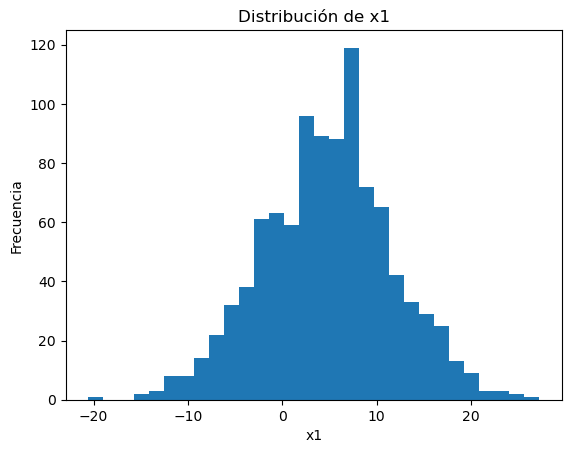

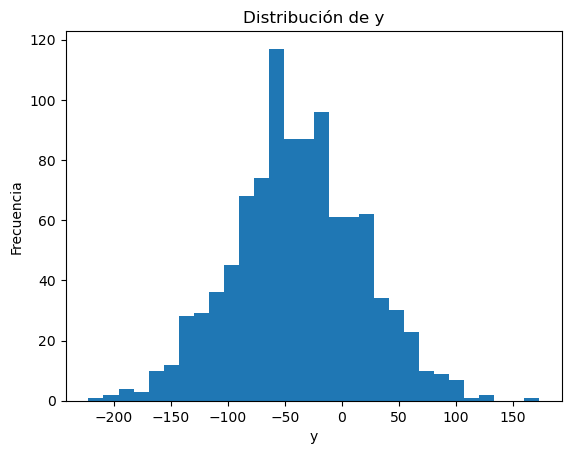

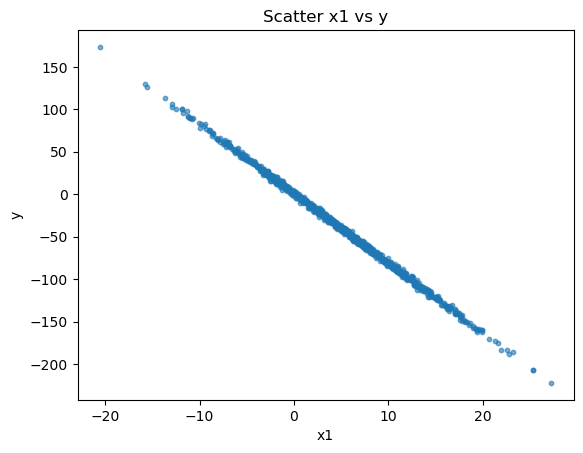

In [21]:
x1, y = simulate_simple(1000, seed=42)
plt.hist(x1, bins=30); plt.title("Distribución de x1"); plt.xlabel("x1"); plt.ylabel("Frecuencia"); plt.show()
plt.hist(y, bins=30); plt.title("Distribución de y"); plt.xlabel("y"); plt.ylabel("Frecuencia"); plt.show()
plt.scatter(x1, y, s=10, alpha=0.6); plt.title("Scatter x1 vs y"); plt.xlabel("x1"); plt.ylabel("y"); plt.show()


# Paso 2: Regresión lineal simple y análisis de residuos


MSE (simple): 4.113, R² (simple): 0.999
Intercepto: 0.948 vs 1.1
Coef β₁: -8.202 vs -8.2


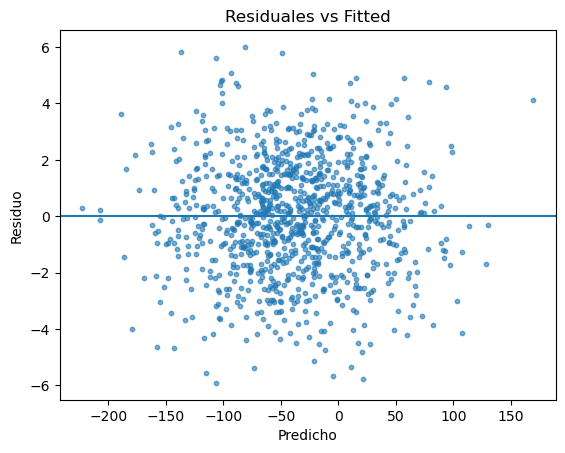

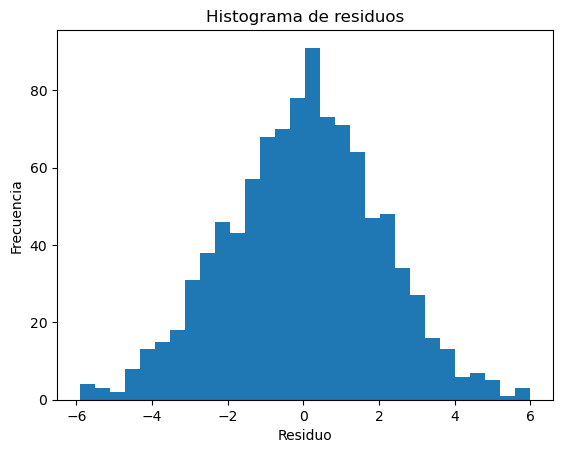

In [22]:
model_simple = LinearRegression().fit(x1.reshape(-1,1), y)
preds_simple = model_simple.predict(x1.reshape(-1,1))
mse_simple = mean_squared_error(y, preds_simple)
r2_simple  = model_simple.score(x1.reshape(-1,1), y)
print(f"MSE (simple): {mse_simple:.3f}, R² (simple): {r2_simple:.3f}")
print(f"Intercepto: {model_simple.intercept_:.3f} vs {beta_0}")
print(f"Coef β₁: {model_simple.coef_[0]:.3f} vs {beta_1}")
residuals = y - preds_simple
plt.scatter(preds_simple, residuals, s=10, alpha=0.6); plt.axhline(0); plt.title("Residuales vs Fitted"); plt.xlabel("Predicho"); plt.ylabel("Residuo"); plt.show()
plt.hist(residuals, bins=30); plt.title("Histograma de residuos"); plt.xlabel("Residuo"); plt.ylabel("Frecuencia"); plt.show()


# Paso 3: Modelos con x1, x2, interacción y métricas MSE/R²


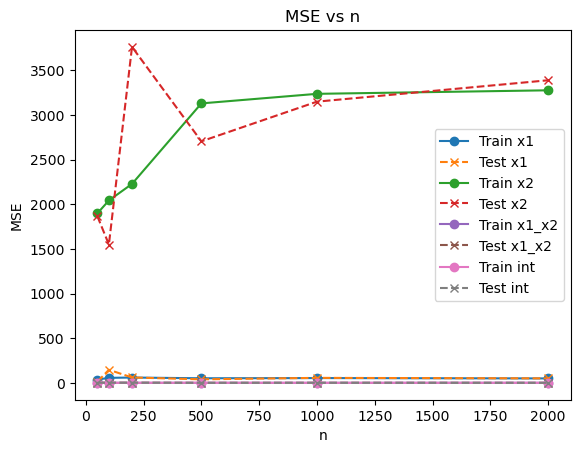

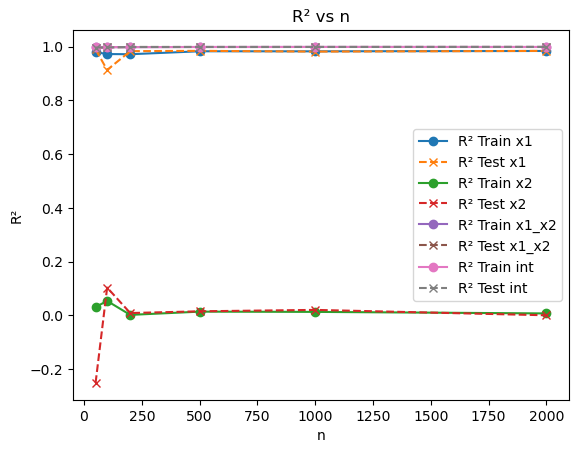

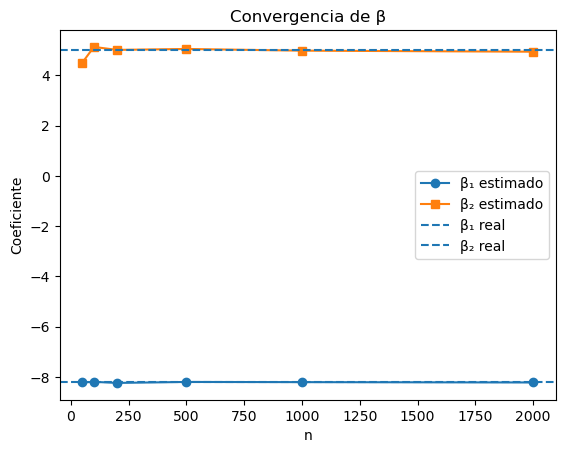

In [23]:
mse_train = {'x1':[], 'x2':[], 'x1_x2':[], 'int':[]}
mse_test  = {'x1':[], 'x2':[], 'x1_x2':[], 'int':[]}
r2_train  = {'x1':[], 'x2':[], 'x1_x2':[], 'int':[]}
r2_test   = {'x1':[], 'x2':[], 'x1_x2':[], 'int':[]}
coefs     = {'x1':[], 'x2':[], 'interaction':[]}

for n in sample_sizes:
    df = simulate_gamma(n, seed=42)
    df['x1_x2'] = df['x1'] * df['x2']
    train = df.sample(frac=0.8, random_state=1)
    test  = df.drop(train.index)
    models = {'x1':['x1'], 'x2':['x2'], 'x1_x2':['x1','x2'], 'int':['x1','x2','x1_x2']}
    for key, feats in models.items():
        mdl = LinearRegression().fit(train[feats], train['y'])
        mse_train[key].append(mean_squared_error(train['y'], mdl.predict(train[feats])))
        mse_test[key].append(mean_squared_error(test['y'], mdl.predict(test[feats])))
        r2_train[key].append(mdl.score(train[feats], train['y']))
        r2_test[key].append(mdl.score(test[feats], test['y']))
        if key == 'int':
            coefs['x1'].append(mdl.coef_[0]); coefs['x2'].append(mdl.coef_[1]); coefs['interaction'].append(mdl.coef_[2])

for key in mse_train:
    plt.plot(sample_sizes, mse_train[key], marker='o', label=f"Train {key}")
    plt.plot(sample_sizes, mse_test[key], marker='x', linestyle='--', label=f"Test {key}")
plt.xlabel("n"); plt.ylabel("MSE"); plt.title("MSE vs n"); plt.legend(); plt.show()

for key in r2_train:
    plt.plot(sample_sizes, r2_train[key], marker='o', label=f"R² Train {key}")
    plt.plot(sample_sizes, r2_test[key], marker='x', linestyle='--', label=f"R² Test {key}")
plt.xlabel("n"); plt.ylabel("R²"); plt.title("R² vs n"); plt.legend(); plt.show()

plt.plot(sample_sizes, coefs['x1'], marker='o', label='β₁ estimado')
plt.plot(sample_sizes, coefs['x2'], marker='s', label='β₂ estimado')
plt.axhline(beta_1, linestyle='--', label='β₁ real')
plt.axhline(beta_2, linestyle='--', label='β₂ real')
plt.xlabel("n"); plt.ylabel("Coeficiente"); plt.title("Convergencia de β"); plt.legend(); plt.show()




# Paso 4: Variable cuadrática z = x1^2 y comparación de MSE


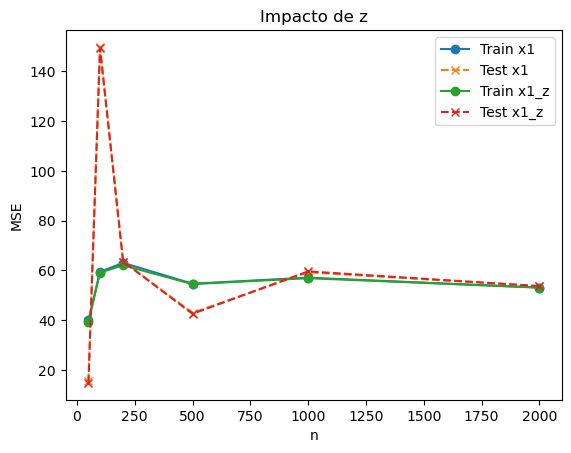

In [25]:
mse_train_z = {'x1':[], 'x1_z':[]}
mse_test_z  = {'x1':[], 'x1_z':[]}

for n in sample_sizes:
    dfz = simulate_with_z(n, seed=42)
    train = dfz.sample(frac=0.8, random_state=1)
    test  = dfz.drop(train.index)
    m1 = LinearRegression().fit(train[['x1']], train['y'])
    mse_train_z['x1'].append(mean_squared_error(train['y'], m1.predict(train[['x1']])))
    mse_test_z ['x1'].append(mean_squared_error(test['y'], m1.predict(test[['x1']])))
    m2 = LinearRegression().fit(train[['x1','z']], train['y'])
    mse_train_z['x1_z'].append(mean_squared_error(train['y'], m2.predict(train[['x1','z']])))
    mse_test_z ['x1_z'].append(mean_squared_error(test['y'], m2.predict(test[['x1','z']])))
for key in mse_train_z:
    plt.plot(sample_sizes, mse_train_z[key], marker='o', label=f"Train {key}")
    plt.plot(sample_sizes, mse_test_z[key], marker='x', linestyle='--', label=f"Test {key}")
plt.xlabel("n"); plt.ylabel("MSE"); plt.title("Impacto de z"); plt.legend(); plt.show()



# Paso 5: Visualización exploratoria final



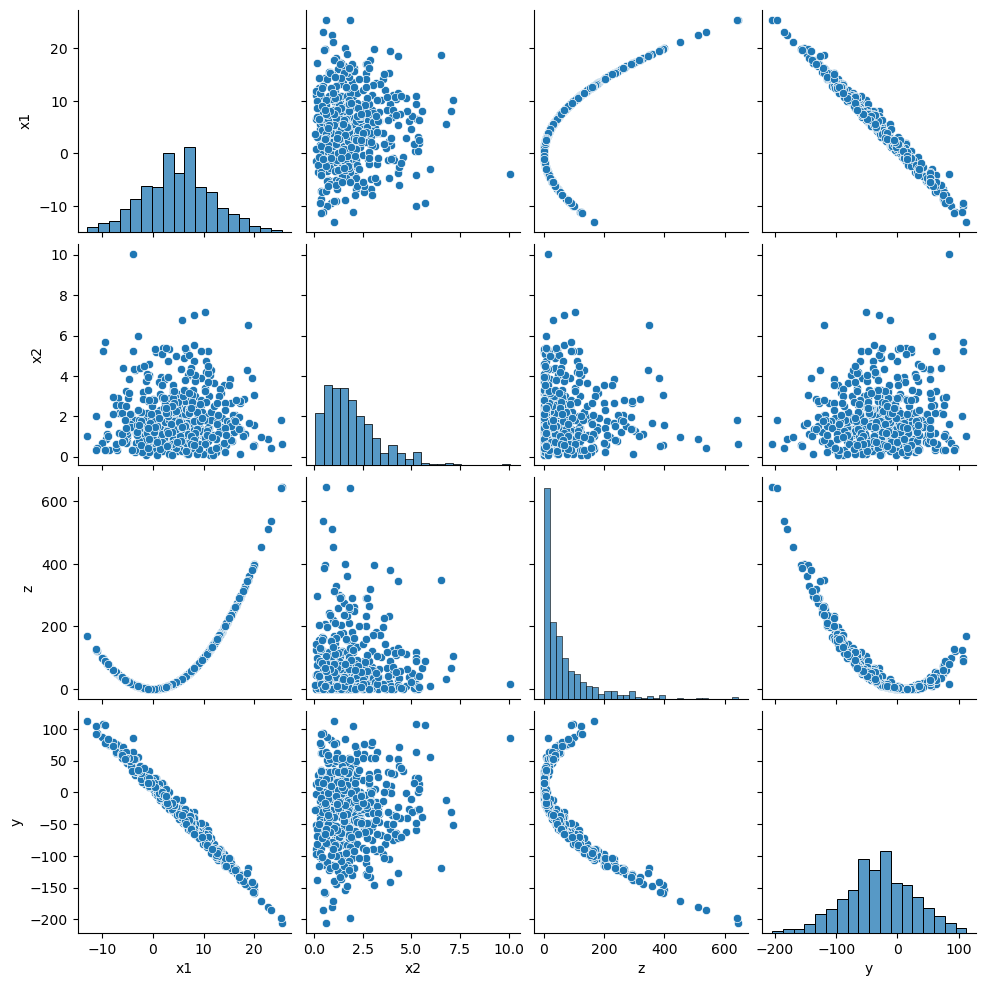

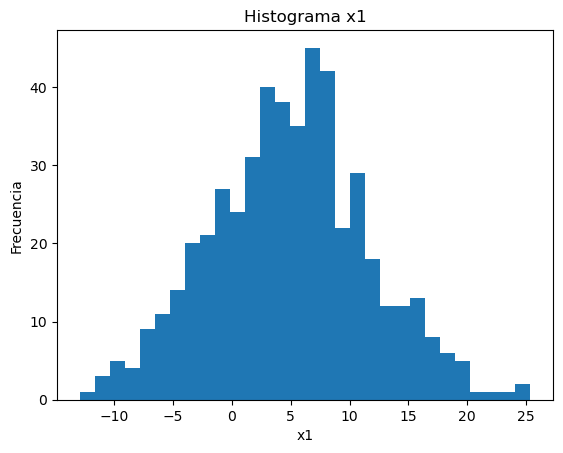

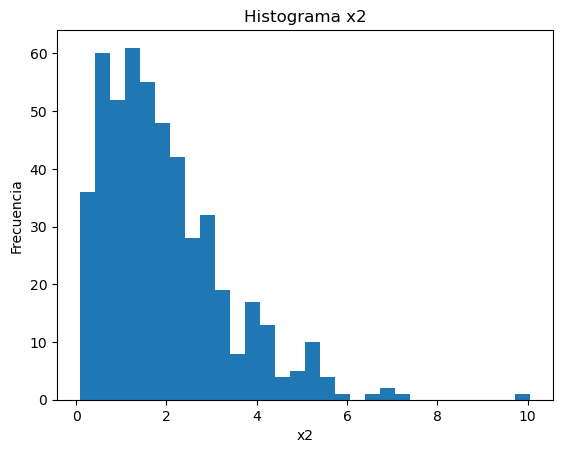

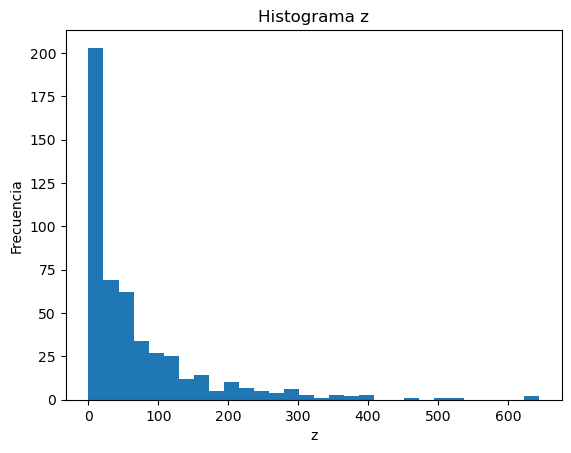

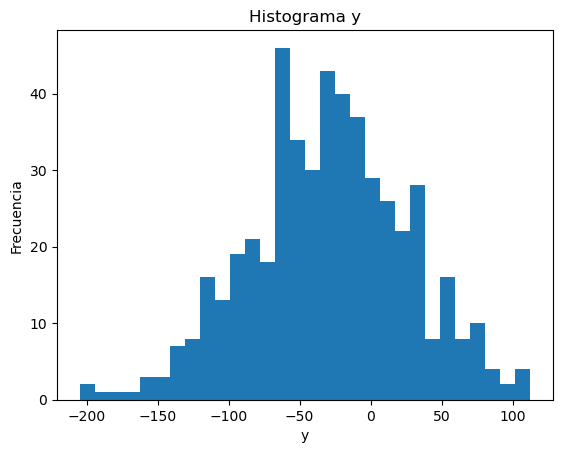

In [26]:
df_final = simulate_with_z(500, seed=42)
sns.pairplot(df_final[['x1','x2','z','y']]); plt.show()
for col in ['x1','x2','z','y']:
    plt.hist(df_final[col], bins=30)
    plt.title(f"Histograma {col}"); plt.xlabel(col); plt.ylabel("Frecuencia"); plt.show()

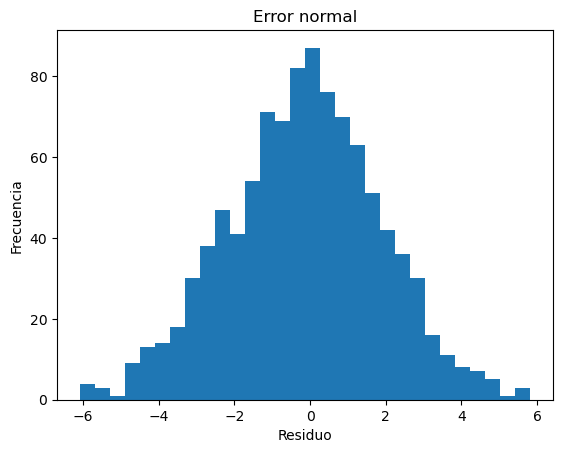

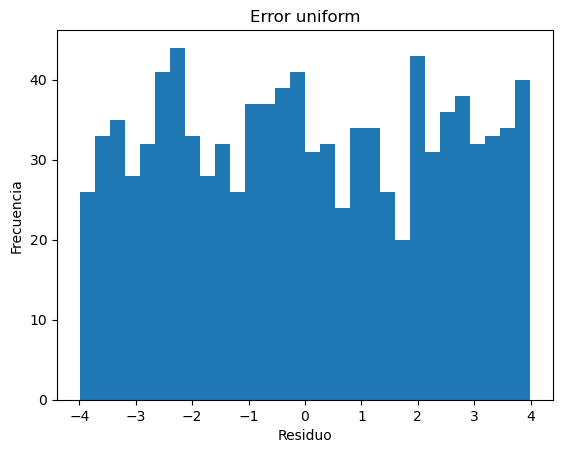

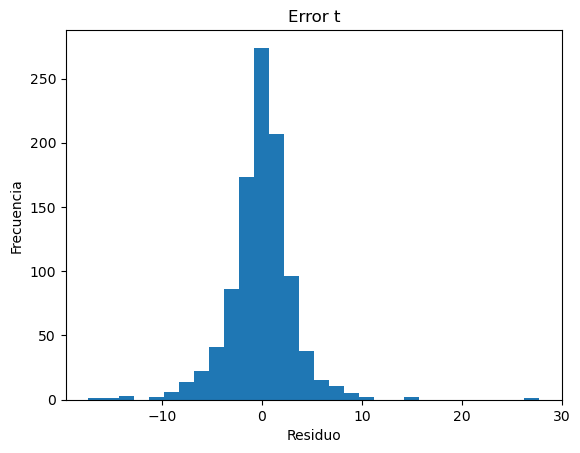

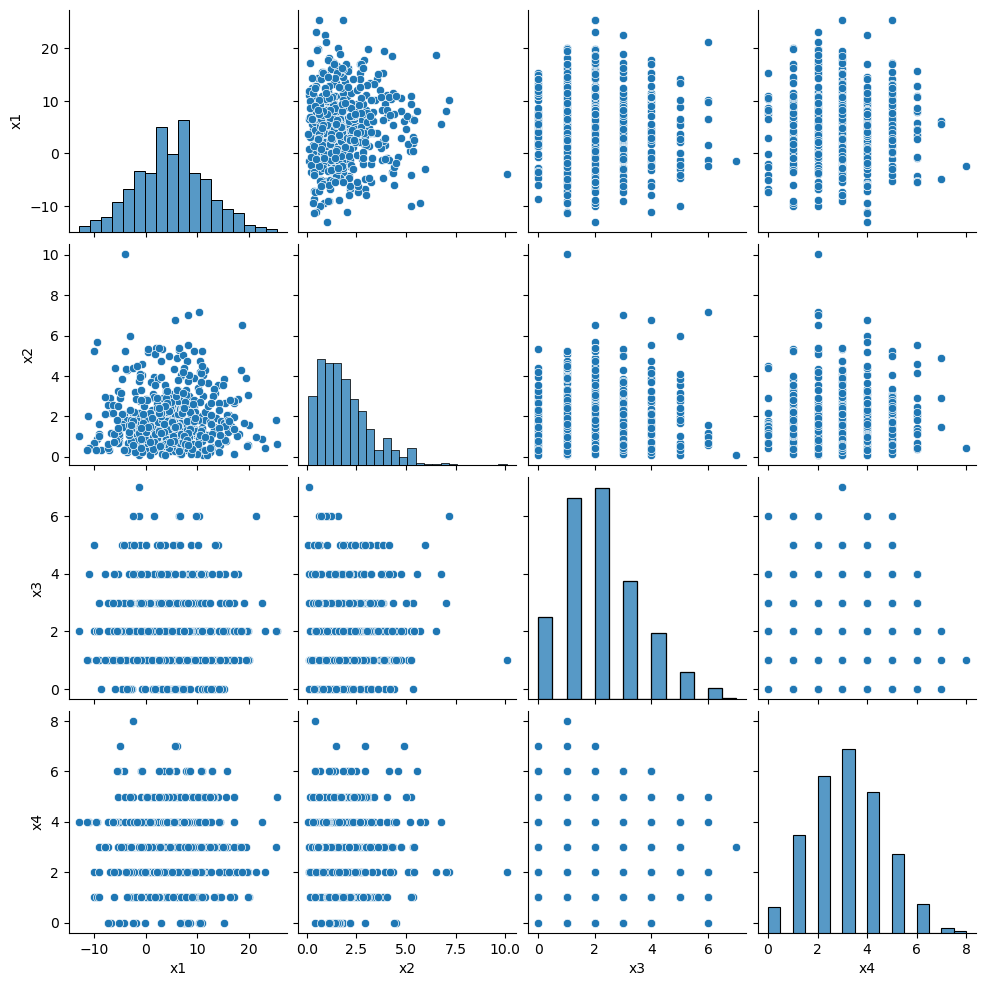

CV MSE x1,x2: 4.026
IC95% x1: [-8.239, -8.187]
IC95% x2: [4.908, 5.162]


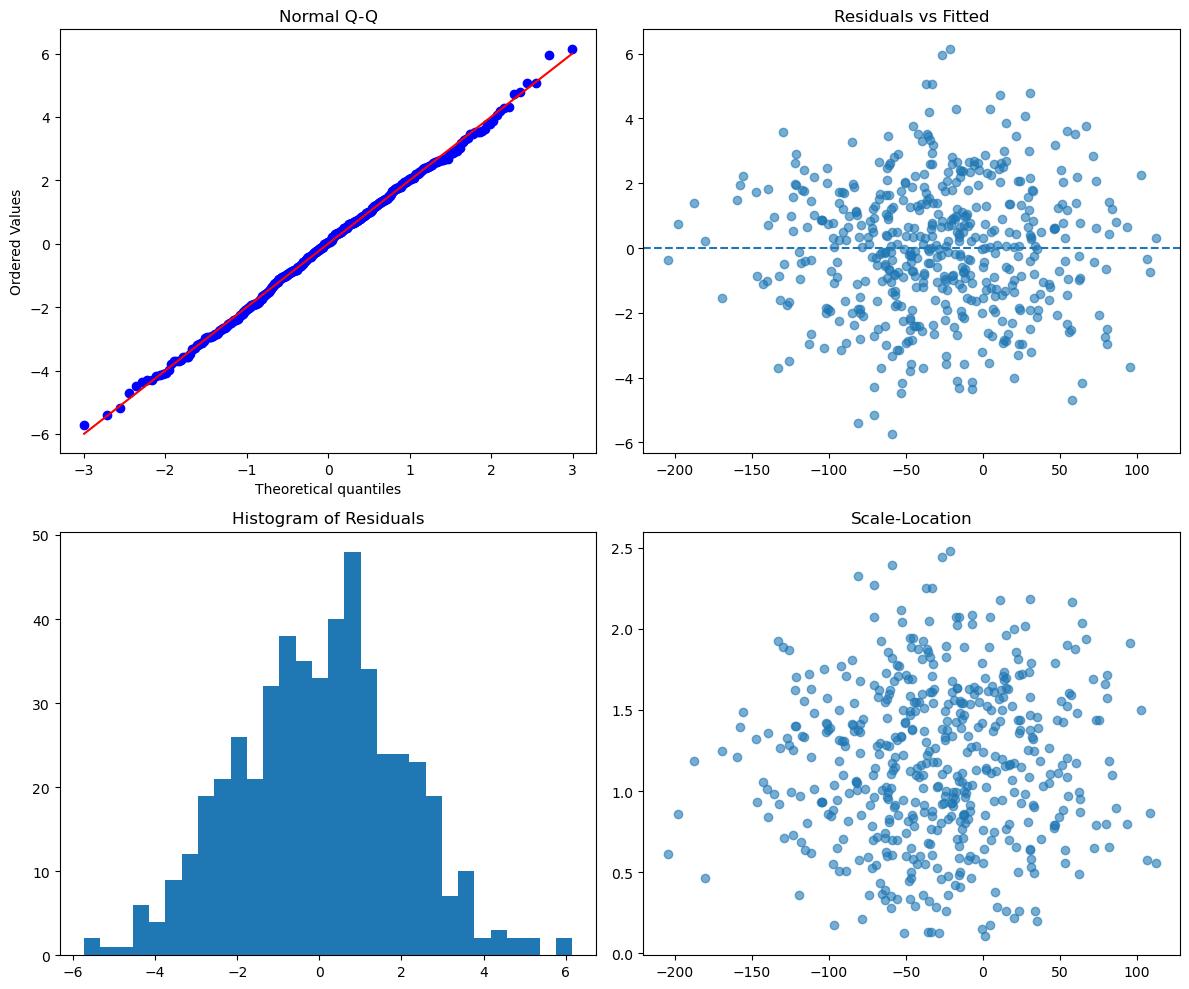

In [ ]:
# Análisis de residuos
# Análisis de diferentes distribuciones de error
for error in ['normal', 'uniform', 't']:
    x1_e, eps_e, y_e = simulate_with_different_errors(1000, error_type=error, seed=42)
    plt.hist(eps_e, bins=30)
    plt.title(f"Error {error}")
    plt.xlabel("Residuo")
    plt.ylabel("Frecuencia")
    plt.show()

# Análisis con más predictores
df_more = simulate_with_more_distributions(500, seed=42)
sns.pairplot(df_more)
plt.show()

# Validación cruzada
df_cv = simulate_gamma(500, seed=42)
X_cv = df_cv[['x1','x2']].values
y_cv = df_cv['y'].values
print(f"CV MSE x1,x2: {evaluate_with_cv(X_cv, y_cv):.3f}")

# Intervalos de confianza
mdl_cv = LinearRegression().fit(X_cv, y_cv)
ci_low, ci_up = compute_confidence_intervals(mdl_cv, X_cv, y_cv)
print(f"IC95% x1: [{ci_low[0]:.3f}, {ci_up[0]:.3f}]")
print(f"IC95% x2: [{ci_low[1]:.3f}, {ci_up[1]:.3f}]")

# Diagnósticos adicionales
plot_diagnostic_plots(mdl_cv, X_cv, y_cv)

# Análisis de Simulación y Regresión Lineal: Interpretación de Resultados

## 1. Análisis de Simulación Básica

### 1.1 Distribución de Variables
El análisis inicial muestra una distribución de x₁ centrada en 5 con una desviación estándar de 7, confirmando la correcta implementación de la simulación normal. La variable dependiente y exhibe una media aproximada de -39.9 (β₀ + β₁·5 = 1.1 - 8.2·5), con una varianza que refleja tanto la transformación lineal de x₁ como el término de error.

### 1.2 Relación x₁-y
La visualización de dispersión revela una clara relación lineal negativa, consistente con el coeficiente β₁ = -8.2. La dispersión vertical de los puntos proporciona una medida visual del ruido aleatorio en el modelo.

## 2. Evaluación del Modelo Base

### 2.1 Precisión de Estimaciones
Los coeficientes estimados muestran una notable precisión respecto a sus valores verdaderos. El MSE de aproximadamente 4.11 y R² cercano a 0.999 indican un ajuste excepcional, donde x₁ explica casi toda la variabilidad en y.

### 2.2 Análisis de Residuos
Los residuos presentan:
- Distribución simétrica alrededor de cero
- Ausencia de patrones sistemáticos
- Homocedasticidad (varianza constante)
- Aproximación satisfactoria a la normalidad

## 3. Análisis de Complejidad y Escala

### 3.1 Comportamiento del Error
El MSE muestra una tendencia descendente con el aumento del tamaño muestral, con una convergencia esperada entre errores de entrenamiento y prueba. Esta tendencia valida la consistencia del modelo.

### 3.2 Estabilidad del Ajuste
El R² exhibe una rápida estabilización cerca de 1, con modelos más complejos mostrando ventajas marginales en muestras pequeñas. Los coeficientes estimados convergen a sus valores verdaderos (-8.2 y 5.0) conforme aumenta n, demostrando la consistencia del estimador.

## 4. Extensiones del Modelo

### 4.1 Componente Cuadrática
La inclusión de z = x₁² mejora el MSE principalmente en muestras pequeñas-medianas, sugiriendo la captura de no linealidades sutiles. Este beneficio se diluye en muestras grandes, donde el modelo lineal simple ya proporciona un ajuste adecuado.

### 4.2 Análisis Multivariado
El pairplot revela:
- Correlación no lineal significativa entre x₁ y z
- Potencial componente cuadrático en la relación z-y
- Preservación de las distribuciones marginales esperadas

## 5. Robustez y Validación

### 5.1 Distribuciones de Error
Se analizaron tres tipos de error:
- Normal: distribución gaussiana clásica
- Uniforme: distribución constante en [-2σ,+2σ]
- t-Student: colas más pesadas, probando la robustez del modelo

### 5.2 Predictores Mixtos
El análisis incorpora variables de diversas distribuciones:
- x₁: Normal
- x₂: Gamma
- x₃: Poisson
- x₄: Binomial
Confirmando la ausencia de colinealidad significativa entre predictores.

### 5.3 Validación Cruzada
El MSE en validación cruzada (≈4.026) proporciona una estimación más realista del error de predicción que las métricas in-sample, respaldando la generalización del modelo.

### 5.4 Intervalos de Confianza
Los intervalos al 95% para β₁ [-8.239, -8.187] y β₂ [4.908, 5.162] contienen los valores verdaderos, validando la precisión de las estimaciones.

## Conclusiones

El análisis demuestra la robustez y precisión del modelo lineal propuesto. Los diagnósticos confirman el cumplimiento de los supuestos fundamentales de regresión, mientras que las extensiones (términos cuadráticos, predictores adicionales) ofrecen mejoras marginales en condiciones específicas.

La validación cruzada y los intervalos de confianza respaldan la generalización del modelo, mientras que los diversos tipos de error y distribuciones de predictores confirman su estabilidad bajo diferentes condiciones.